### ***Model Building***

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [66]:
def plot_confusion_matrix(y,y_predict):
    from sklearn.metrics import confusion_matrix
    cm=confusion_matrix(y,y_predict)
    ax=plt.subplot()
    sns.heatmap(cm,annot=True,ax=ax)
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

In [67]:
# import dataset
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
dataframe=pd.read_csv(url)
if dataframe is not None :
    print('Data read successful')
else :
    print('Failed to read data')

Data read successful


In [68]:
# supporting variables
x=pd.read_csv(f'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')

In [69]:
# predicting variable
y=dataframe['Class'].to_numpy()

In [70]:
# standarlize x data
transform=preprocessing.StandardScaler()
x=transform.fit_transform(x)

In [71]:
# split the data set
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=2)

In [72]:
# logistic regression
parameters={
    'C':[0.01,0.1,1],
    'penalty':['l2'],
    'solver':['lbfgs']
    }
lr=LogisticRegression()

In [73]:
# grid search cv
grid_lr=GridSearchCV(lr,param_grid=parameters)

In [74]:
# train with data
grid_lr.fit(xtrain,ytrain)

GridSearchCV(estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1], 'penalty': ['l2'],
                         'solver': ['lbfgs']})

In [75]:
# predict
y_predict=grid_lr.predict(xtest)

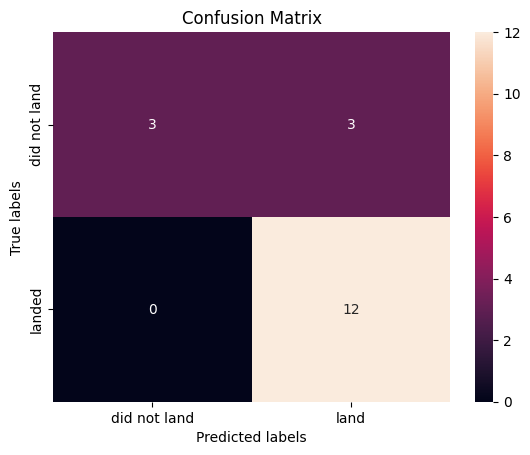

In [76]:
# confusion matrix
plot_confusion_matrix(ytest,y_predict)


In [77]:
# best params
grid_lr.best_params_

{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}

In [78]:
# accuracy of model
from sklearn.metrics import accuracy_score
round(accuracy_score(ytest,y_predict)*100,2)

83.33

In [79]:
# support vector machine
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()


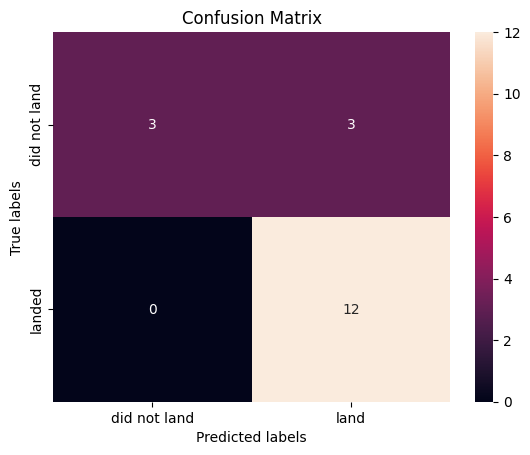

In [80]:
# grid search cv
grid_svm=GridSearchCV(svm,param_grid=parameters)
grid_svm.fit(xtrain,ytrain)
y_predict=grid_svm.predict(xtest)
plot_confusion_matrix(ytest,y_predict)

In [81]:
# best paramas
grid_svm.best_params_

{'C': np.float64(0.03162277660168379),
 'gamma': np.float64(0.001),
 'kernel': 'linear'}

In [82]:
# accuracy
round(accuracy_score(ytest,y_predict)*100,2) 


83.33

In [83]:
# decison tree 
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['auto', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()


c:\Users\Mayank chouhan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
1620 fits failed out of a total of 3240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1620 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Mayank chouhan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Mayank chouhan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~

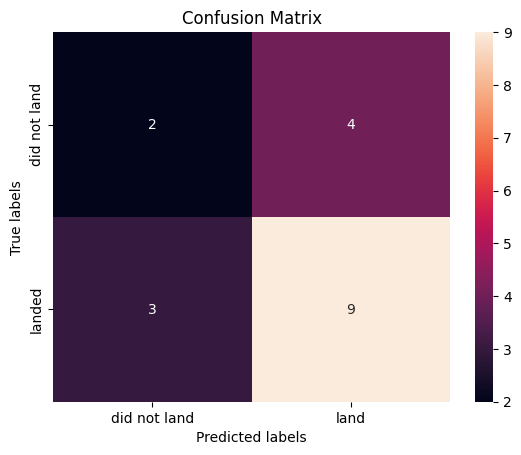

In [84]:
# grid search
grid_dt=GridSearchCV(tree,param_grid=parameters)
grid_dt.fit(xtrain,ytrain)
y_predict=grid_dt.predict(xtest)
plot_confusion_matrix(ytest,y_predict)

In [85]:
# accuracy
round(accuracy_score(ytest,y_predict),2)*100

61.0

In [86]:
# best paramas
grid_dt.best_params_

{'criterion': 'gini',
 'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'splitter': 'random'}

In [87]:
# k nearest neigbors
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()

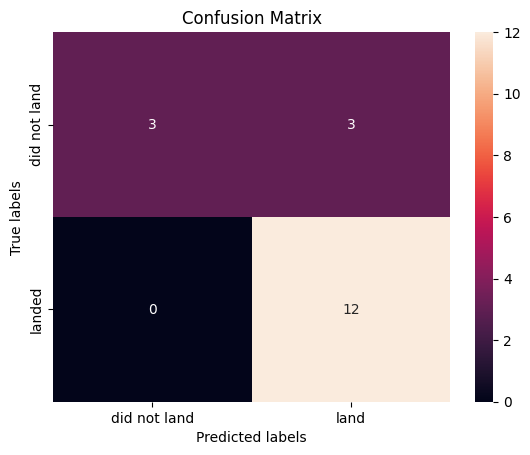

In [88]:
# grid search
grid_knn=GridSearchCV(KNN,param_grid=parameters)
grid_knn.fit(xtrain,ytrain)
y_predict=grid_knn.predict(xtest)
plot_confusion_matrix(ytest,y_predict)

In [89]:
# accuracy
round(accuracy_score(ytest,y_predict),2)*100

83.0

In [90]:
# best paramas
grid_knn.best_params_

{'algorithm': 'auto', 'n_neighbors': 8, 'p': 1}

In [92]:
# every algorithim performed same for the given data for more efficecy we can go with svm

In [93]:
ytest.shape

(18,)